In [ ]:
import numpy as np
import cvxpy as cp

# Dimensions
n, p = 15, 8

# Matrices données
X = np.array([
    [1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0],
    [0,0,0,1,0,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,1],
    [1,1,0,0,0,0,0,0],
    [0,0,1,1,0,0,0,0],
    [0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,1,1],
    [1,0,1,0,0,0,0,0],
    [0,1,0,1,0,0,0,0],
    [1,1,1,1,0,0,0,0]
])

R = np.array([
    [1,0,1,0,-1,0,-1,0],
    [0,1,0,1,0,-1,0,-1],
    [1,1,1,1,-1,-1,-1,-1]
])

# Données fictives
Y = np.array([20, 12, 23, 10, 7, 9, 13, 21, 23, 24, 25, 20, 20, 27, 59])
sigma2 = np.linspace(10, 30, 15)  # variances hétéroscédastiques
Omega = np.diag(sigma2)
Omega_inv = np.diag(1 / sigma2)

# Variables
beta = cp.Variable(p)

# Objectif : moindres carrés pondérés
objective = cp.Minimize(cp.quad_form(Y - X @ beta, Omega_inv))

# Contraintes
constraints = [
    R @ beta == 0,
    beta >= 0
]

# Problème
problem = cp.Problem(objective, constraints)
problem.solve()

X_beta = X @ beta.value
X_beta_rounded = np.round(X_beta).astype(int)
print("X*beta estimé :", X_beta_rounded)

X*beta estimé : [13 13 15 12 14 10 14 15 26 27 24 29 28 25 53]


Beta estimé: [ 1.43174964e-01 -6.17278771e-22  3.94822843e-01  3.59713057e-01
 -1.95251720e-21 -1.41554911e-21  5.37997807e-01  3.59713057e-01]


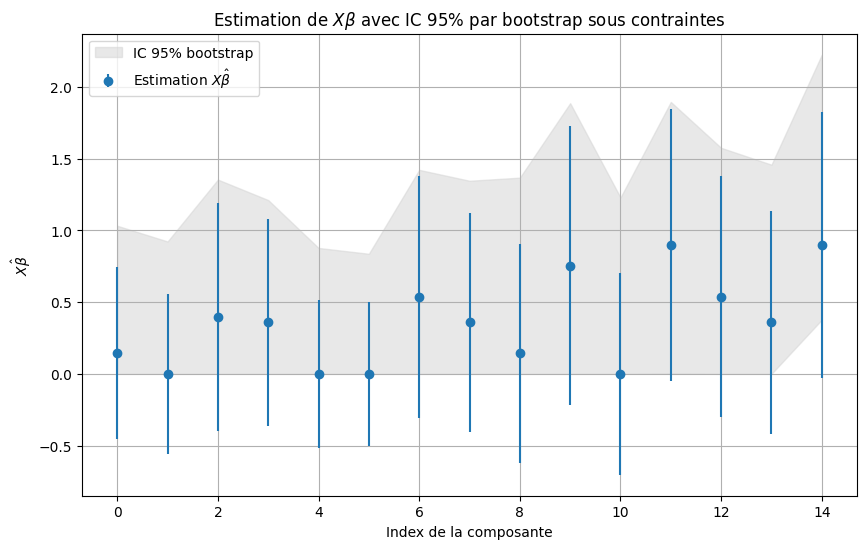

In [15]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# Données d'exemple (à remplacer par tes données)
n, p = 15, 8
X = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 0, 0, 0]
])
Omega_diag = np.ones(n)  # Exemple : variance unitaire, adapte si besoin
Omega_sqrt = np.sqrt(Omega_diag)

R = np.array([
    [1, 0, 1, 0, -1, 0, -1, 0],
    [0, 1, 0, 1, 0, -1, 0, -1],
    [1, 1, 1, 1, -1, -1, -1, -1]
])

# Vecteur Y observé (exemple aléatoire)
np.random.seed(42)
beta_true = np.array([0.3, 0.4, 0.1, 0.5, 0.4, 0.0, 0.0, 0.8])
epsilon = np.random.normal(0, 1, n)
Y = X @ beta_true + epsilon

# --- Estimation initiale ---

beta = cp.Variable(p)
objective = cp.Minimize(cp.sum_squares(cp.multiply(1 / Omega_sqrt, X @ beta - Y)))
constraints = [R @ beta == 0, beta >= 0]
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.OSQP)

beta_hat = beta.value
X_beta_hat = X @ beta_hat

print("Beta estimé:", beta_hat)

# --- Bootstrap pour variance ---

B = 500  # nombre de simulations bootstrap
X_beta_bootstrap = np.zeros((n, B))

for b in range(B):
    epsilon_b = np.random.normal(0, Omega_sqrt)  # bruit selon Omega
    Y_b = X_beta_hat + epsilon_b

    beta_b = cp.Variable(p)
    obj_b = cp.Minimize(cp.sum_squares(cp.multiply(1 / Omega_sqrt, X @ beta_b - Y_b)))
    cons_b = [R @ beta_b == 0, beta_b >= 0]
    prob_b = cp.Problem(obj_b, cons_b)
    prob_b.solve(solver=cp.OSQP)

    if beta_b.value is not None:
        X_beta_bootstrap[:, b] = X @ beta_b.value
    else:
        X_beta_bootstrap[:, b] = np.nan  # si problème

# Variance empirique
X_beta_var = np.nanvar(X_beta_bootstrap, axis=1)
X_beta_std = np.sqrt(X_beta_var)

# Intervalle de confiance à 95%
ci_lower = np.nanpercentile(X_beta_bootstrap, 2.5, axis=1)
ci_upper = np.nanpercentile(X_beta_bootstrap, 97.5, axis=1)

# --- Affichage graphique ---

plt.figure(figsize=(10, 6))
plt.errorbar(range(n), X_beta_hat, yerr=1.96 * X_beta_std, fmt='o', label='Estimation $X\\hat{\\beta}$')
plt.fill_between(range(n), ci_lower, ci_upper, color='lightgray', alpha=0.5, label='IC 95% bootstrap')
plt.xlabel('Index de la composante')
plt.ylabel('$X\\hat{\\beta}$')
plt.title('Estimation de $X\\beta$ avec IC 95% par bootstrap sous contraintes')
plt.legend()
plt.grid(True)
plt.show()
